## Check far-field distance is <2.5 m

In [ ]:
FREQUENCY = 868e6 # Hz

# Balanis, Antenna Theory, sec 4.4.1
def wavelength(freq):
    return 3e8 / freq

HALF_WAVE_DIPOLE_LENGTH = wavelength(FREQUENCY) * .5
print(f"Antenna length {HALF_WAVE_DIPOLE_LENGTH:.3f} m")

# Balanis
radius = (2 * HALF_WAVE_DIPOLE_LENGTH**2) / wavelength(FREQUENCY)
print(f"Far-field boundary: {radius:.3f} m")

Antenna length 0.173 m
Far-field boundary: 0.173 m


## Log-distance path loss

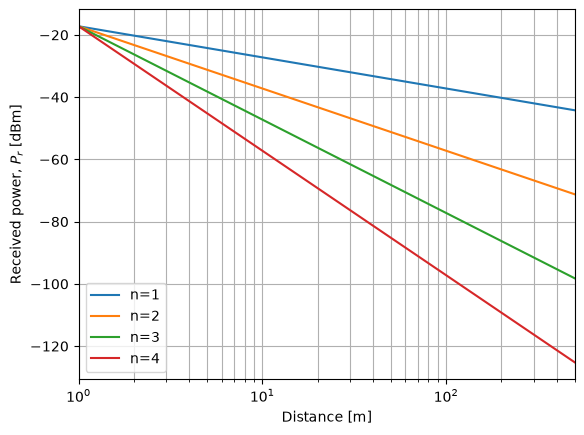

In [106]:
import numpy as np
import matplotlib.pyplot as plt


# Goldsmith, Wireless Communication, sec. 2.6
def rx_power_dB(distance, freq, loss_exponent=2, tx_power=14):
    K = 147.55 - 20 * np.log10(freq)
    return tx_power + K - 10 * loss_exponent * np.log10(distance)

distances = np.linspace(1, 500, 1000)
path_loss = rx_power_dB(distances, FREQUENCY)


for n in [1, 2, 3, 4]:
    path_loss = rx_power_dB(distances, FREQUENCY, n)
    plt.semilogx(distances, path_loss, label=f"n={n}")
plt.xlabel("Distance [m]")
plt.ylabel("Received power, $P_r$ [dBm]")
plt.grid(True, which="both")
plt.legend()
plt.xlim(min(distances), max(distances))
plt.show()

## Path loss from attenuation factor
Complex propagation constant for general lossy material $\gamma = \alpha + j\beta=j\omega\sqrt{\mu\epsilon}$ - (Pozar Table 1.1).

Attenuation factors: 0.08 dB/m 0.11 dB/m 0.14 dB/m 

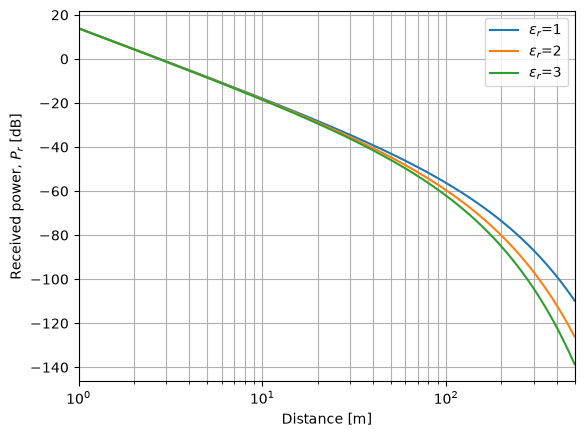

In [107]:
mu_vacuum = 4 * np.pi * 1e-7
mu = mu_vacuum
delta = 1e-3 # Tangent loss
omega = 2 * np.pi * FREQUENCY
epsilon_vaccum = 1/(36*np.pi) * 1e-9
epsilon_insulation = np.array([1, 2, 3]) 
epsilon_complex = epsilon_vaccum * epsilon_insulation * (1 - 1j * np.tan(delta))

gamma_Np = 1j * omega * np.sqrt(mu * epsilon_complex)
gamma_dB = 20/np.log(10) * gamma_Np
alpha_dB = gamma_dB.real
print("Attenuation factors:", end=" ")
for val in alpha_dB:
    print(f"{val:.2f} dB/m", end=" ")

def rx_power_dB(distance, freq, alpha, tx_power=14):
    K = 147.55 - 20 * np.log10(freq)
    return tx_power + K * np.log10(distance) - alpha * distance

for alpha, epsilon in zip(alpha_dB, epsilon_insulation):
    path_loss = rx_power_dB(distances, FREQUENCY, alpha)
    plt.semilogx(distances, path_loss, label=f"$\\epsilon_r$={epsilon}")
plt.xlabel("Distance [m]")
plt.ylabel("Received power, $P_r$ [dB]")
plt.grid(True, which="both")
plt.legend()
plt.xlim(min(distances), max(distances))
plt.show()

## Peplinski VWC loss

Uses the relation $\epsilon = \epsilon' - j\epsilon''$

Attenuation factors: 5.93e+06 dB/m 9.68e+06 dB/m 

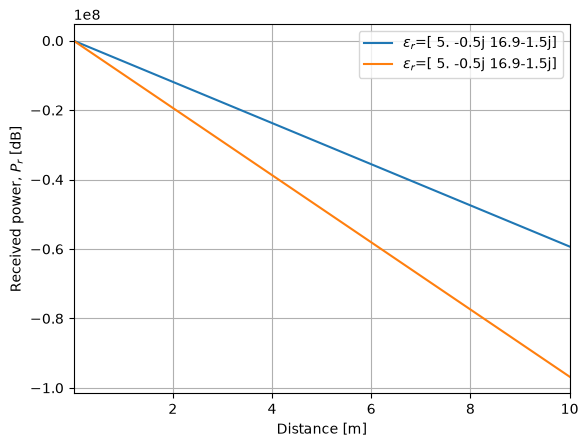

In [ ]:
epsilon_vwc = np.array([5 - 1j*0.5, 16.9 - 1j*1.5]) # 5% and 25% VWC @1.3GHz
gamma_dB = 1j * omega * np.sqrt(mu * epsilon_vwc) * 20/np.log(10)
alpha_dB = gamma_dB.real
print("Attenuation factors:", end=" ")
for val in alpha_dB:
    print(f"{val:.2e} dB/m", end=" ")

distances = np.linspace(1e-3, 10, 1000)

for alpha, epsilon in zip(alpha_dB, epsilon_vwc):
    path_loss = rx_power_dB(distances, FREQUENCY, alpha)
    plt.plot(distances, path_loss, label=f"$\\epsilon_r$={epsilon_vwc}")
plt.xlabel("Distance [m]")
plt.ylabel("Received power, $P_r$ [dB]")
plt.grid(True, which="both")
plt.legend()
plt.xlim(min(distances), max(distances))
plt.show()
